In [1]:
!pip install -q transformers accelerate bitsandbytes sentencepiece
!pip install -q sentence-transformers

import os
import json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel
from sklearn.metrics import f1_score, classification_report
from sentence_transformers import SentenceTransformer
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 31.6 MB/s eta 0:00:00:00:0100:01
Device: cuda


In [2]:
base_path = "/kaggle/input/datasets/llmkhushbu/humanvalue/10564870" 

In [3]:
train_args = pd.read_csv(f"{base_path}/arguments-training.tsv", sep="\t")
val_args   = pd.read_csv(f"{base_path}/arguments-validation.tsv", sep="\t")

train_labels = pd.read_csv(f"{base_path}/labels-training.tsv", sep="\t")
val_labels   = pd.read_csv(f"{base_path}/labels-validation.tsv", sep="\t")

train_df = pd.merge(train_args, train_labels, on="Argument ID")
val_df   = pd.merge(val_args, val_labels, on="Argument ID")

print(f"Train samples: {len(train_df)}, Val samples: {len(val_df)}")

Train samples: 5393, Val samples: 1896


In [4]:
with open(f"{base_path}/value-categories.json", "r", encoding="utf-8") as f:
    value_categories = json.load(f)

print("Value categories loaded successfully.")
print(f"Categories: {list(value_categories.keys())[:5]}...")

Value categories loaded successfully.
Categories: ['Self-direction: thought', 'Self-direction: action', 'Stimulation', 'Hedonism', 'Achievement']...


In [5]:
# Build text
def build_text(df):
    return (
        "Conclusion: " + df["Conclusion"].fillna("").astype(str) +
        " [SEP] Stance: " + df["Stance"].fillna("").astype(str) +
        " [SEP] Premise: " + df["Premise"].fillna("").astype(str)
    )

X_train = build_text(train_df).reset_index(drop=True)
X_val   = build_text(val_df).reset_index(drop=True)

# Labels
label_cols = [c for c in train_labels.columns if c != "Argument ID"]

y_train = (
    train_df[label_cols]
    .fillna(0)
    .clip(0, 1)
    .astype(np.float32)
    .reset_index(drop=True)
    .values
)

y_val = (
    val_df[label_cols]
    .fillna(0)
    .clip(0, 1)
    .astype(np.float32)
    .reset_index(drop=True)
    .values
)
print("Train text shape:", X_train.shape)
print("Train label shape:", y_train.shape)
print("Unique label values:", np.unique(y_train))
print("Sample text:\n", X_train.iloc[0])
print("Sample labels:\n", y_train[0])
print("Num labels:", len(label_cols))
print("Label columns:", label_cols)

Train text shape: (5393,)
Train label shape: (5393, 20)
Unique label values: [0. 1.]
Sample text:
 Conclusion: We should ban human cloning [SEP] Stance: in favor of [SEP] Premise: we should ban human cloning as it will only cause huge issues when you have a bunch of the same humans running around all acting the same.
Sample labels:
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Num labels: 20
Label columns: ['Self-direction: thought', 'Self-direction: action', 'Stimulation', 'Hedonism', 'Achievement', 'Power: dominance', 'Power: resources', 'Face', 'Security: personal', 'Security: societal', 'Tradition', 'Conformity: rules', 'Conformity: interpersonal', 'Humility', 'Benevolence: caring', 'Benevolence: dependability', 'Universalism: concern', 'Universalism: nature', 'Universalism: tolerance', 'Universalism: objectivity']


# **Baseline: all-MiniLM-L6-v2 + Logistic Regression**
This baseline uses sentence embeddings with a simple OneVsRest classifier. It serves as a comparison point for the DeBERTa model.

In [6]:
# Baseline Model: Sentence Embeddings + Logistic Regression
"""print("Downloading and loading the embedding model...")
embedder = SentenceTransformer('all-MiniLM-L6-v2')

train_texts = X_train.tolist()
val_texts   = X_val.tolist()

print("Encoding training data...")
X_train_vec = embedder.encode(train_texts, show_progress_bar=True)

print("Encoding validation data...")
X_val_vec = embedder.encode(val_texts, show_progress_bar=True)

print("Train vector shape:", X_train_vec.shape)
print("Val vector shape:",   X_val_vec.shape)"""

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

Encoding training data...


Batches:   0%|          | 0/169 [00:00<?, ?it/s]

Encoding validation data...


Batches:   0%|          | 0/60 [00:00<?, ?it/s]

Train vector shape: (5393, 384)
Val vector shape: (1896, 384)


In [7]:
"""baseline_model = OneVsRestClassifier(
    LogisticRegression(max_iter=2000, class_weight="balanced")
)

baseline_model.fit(X_train_vec, y_train)
print("Baseline model training complete.")"""

Baseline model training complete.


In [8]:
"""y_pred_baseline = baseline_model.predict(X_val_vec)

micro_f1 = f1_score(y_val, y_pred_baseline, average='micro', zero_division=0)
macro_f1 = f1_score(y_val, y_pred_baseline, average='macro', zero_division=0)

print(f"Baseline Micro F1: {micro_f1:.4f}")
print(f"Baseline Macro F1: {macro_f1:.4f}")

report    = classification_report(y_val, y_pred_baseline, target_names=label_cols, zero_division=0, output_dict=True)
report_df = pd.DataFrame(report).transpose()
display(report_df.sort_values("f1-score", ascending=False).head(15))"""

Baseline Micro F1: 0.4526
Baseline Macro F1: 0.4073


,precision,recall,f1-score,support
Security: personal,0.679380,0.750988,0.713392,759.0
Achievement,0.557181,0.728696,0.631500,575.0
Security: societal,0.538843,0.668033,0.596523,488.0
Universalism: concern,0.511654,0.671033,0.580605,687.0
Universalism: nature,0.464455,0.771654,0.579882,127.0
Benevolence: caring,0.412033,0.714060,0.522543,633.0
Self-direction: action,0.408088,0.671371,0.507622,496.0
weighted avg,0.411078,0.665985,0.494237,6359.0
Power: resources,0.345277,0.803030,0.482916,132.0
Conformity: rules,0.357374,0.729670,0.479769,455.0


In [9]:
"""def predict_level1_scores(conclusion, stance, premise):
    """Predict value scores using the baseline MiniLM + LogReg model."""
    text = f"Conclusion: {conclusion} [SEP] Stance: {stance} [SEP] Premise: {premise}"
    vec  = embedder.encode([text])
    probs = np.array([clf.predict_proba(vec)[0][1] for clf in baseline_model.estimators_])
    return {label_cols[i]: float(probs[i]) for i in range(len(label_cols))}"""

# **Primary Model: DeBERTa-v3 Fine-Tuned Classifier**
Fine-tuned DeBERTa-v3-small for multi-label human value classification. This model provides the value scores used by the Schwartz-framework agents.

In [23]:
# DeBERTa Setup: Tokenizer + Dataset
model_name = "microsoft/deberta-v3-small"
tokenizer = AutoTokenizer.from_pretrained(model_name)

class ValueDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts = list(texts)
        self.labels = labels.astype(np.float32)

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=256,
            return_tensors="pt"
        )

        item = {
            "input_ids": enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "labels": torch.tensor(self.labels[idx], dtype=torch.float32)
        }
        return item

train_data = ValueDataset(X_train, y_train)
val_data   = ValueDataset(X_val, y_val)

train_loader = DataLoader(train_data, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_data, batch_size=16)

print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")

Train batches: 338, Val batches: 119


In [24]:

# Model Definition
class DebertaClassifier(nn.Module):
    def __init__(self, num_labels):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        hidden = self.encoder.config.hidden_size
        self.dropout = nn.Dropout(0.2)
        self.fc = nn.Linear(hidden, num_labels)

    def forward(self, input_ids, attention_mask):
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        cls = out.last_hidden_state[:, 0, :].float()   # safe cast for mixed-precision
        x   = self.dropout(cls)
        return self.fc(x)

deberta_model = DebertaClassifier(num_labels=len(label_cols)).to(device)

# NOTE: model.float() is intentionally kept.
# DeBERTa-v3 loads some internal layers (disentangled attention, embeddings)
# in float16 / bfloat16 on Kaggle GPUs. Without this full model cast to FP32,
# dtype mismatches between encoder output and the linear head produce NaN loss
# from the very first batch.
deberta_model = deberta_model.float()

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(deberta_model.parameters(), lr=2e-5)

print(f"DeBERTa model loaded. Parameters: {sum(p.numel() for p in deberta_model.parameters()):,}")

Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-small
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
mask_predictions.dense.bias             | UNEXPECTED |  | 
mask_predictions.classifier.weight      | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 
mask_predictions.classifier.bias        | UNEXPECTED |  | 
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


DeBERTa model loaded. Parameters: 141,319,700


Epoch 1/5, Train Loss: 0.4454
Epoch 2/5, Train Loss: 0.3559
Epoch 3/5, Train Loss: 0.3253
Epoch 4/5, Train Loss: 0.3073
Epoch 5/5, Train Loss: 0.2965
Model saved to deberta_values.pt


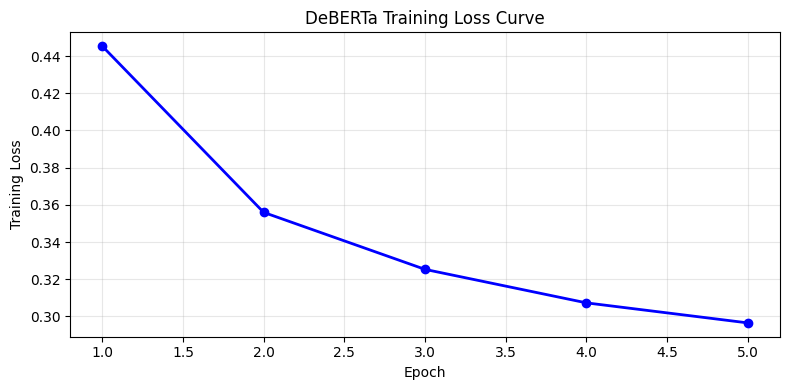

In [25]:
from transformers import get_linear_schedule_with_warmup

epochs = 5
total_steps  = len(train_loader) * epochs
warmup_steps = int(0.1 * total_steps)   # 10% warmup

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

train_losses = []

for epoch in range(epochs):
    deberta_model.train()
    total_loss  = 0
    nan_batches = 0

    for batch in train_loader:
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels         = batch["labels"].to(device)

        optimizer.zero_grad()
        logits = deberta_model(input_ids, attention_mask)
        loss   = criterion(logits, labels)

        # NaN guard — skip corrupt batch instead of poisoning weights
        if torch.isnan(loss):
            nan_batches += 1
            continue

        loss.backward()
        torch.nn.utils.clip_grad_norm_(deberta_model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()

    valid_batches = len(train_loader) - nan_batches
    avg_loss = total_loss / valid_batches if valid_batches > 0 else float("nan")
    train_losses.append(avg_loss)
    print(f"Epoch {epoch+1}/{epochs}, Train Loss: {avg_loss:.4f}"
          + (f"  [skipped {nan_batches} NaN batches]" if nan_batches else ""))

torch.save(deberta_model.state_dict(), "deberta_values.pt")
print("Model saved to deberta_values.pt")

# Plot training loss
plt.figure(figsize=(8, 4))
plt.plot(range(1, epochs+1), train_losses, 'b-o', linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("DeBERTa Training Loss Curve")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [26]:
# Evaluate with Optimal Threshold Search
deberta_model.eval()
all_probs  = []
all_labels = []

with torch.no_grad():
    for batch in val_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].cpu().numpy()

        logits = deberta_model(input_ids, attention_mask)
        probs = torch.sigmoid(logits).cpu().numpy()

        all_probs.append(probs)
        all_labels.append(labels)

y_probs = np.vstack(all_probs)
y_true  = np.vstack(all_labels)

best_thresh = 0.3
best_micro  = 0.0
for t in np.arange(0.2, 0.55, 0.05):
    preds = (y_probs >= t).astype(int)
    micro = f1_score(y_true, preds, average="micro", zero_division=0)
    if micro > best_micro:
        best_micro  = micro
        best_thresh = t

print(f"Optimal threshold: {best_thresh:.2f}")

y_pred = (y_probs >= best_thresh).astype(int)

print(f"DeBERTa Micro F1: {f1_score(y_true, y_pred, average='micro', zero_division=0):.4f}")
print(f"DeBERTa Macro F1: {f1_score(y_true, y_pred, average='macro', zero_division=0):.4f}")

report = classification_report(
    y_true,
    y_pred,
    target_names=label_cols,
    zero_division=0,
    output_dict=True
)

display(pd.DataFrame(report).transpose())

Optimal threshold: 0.25
DeBERTa Micro F1: 0.5380
DeBERTa Macro F1: 0.3790


,precision,recall,f1-score,support
Self-direction: thought,0.375315,0.593625,0.459877,251.0
Self-direction: action,0.497470,0.594758,0.541781,496.0
Stimulation,0.608696,0.101449,0.173913,138.0
Hedonism,0.363636,0.038835,0.070175,103.0
Achievement,0.553763,0.716522,0.624716,575.0
Power: dominance,0.358491,0.231707,0.281481,164.0
Power: resources,0.400966,0.628788,0.489676,132.0
Face,0.000000,0.000000,0.000000,130.0
Security: personal,0.573715,0.897233,0.699897,759.0
Security: societal,0.479578,0.745902,0.583801,488.0


In [27]:
def predict_level1_scores(conclusion, stance, premise):
    """Predict value scores using the fine-tuned DeBERTa model."""
    text = f"Conclusion: {conclusion} [SEP] Stance: {stance} [SEP] Premise: {premise}"

    deberta_model.eval()

    enc = tokenizer(
        text,
        truncation=True,
        padding="max_length",
        max_length=256,
        return_tensors="pt"
    )

    input_ids = enc["input_ids"].to(device)
    attention_mask = enc["attention_mask"].to(device)

    with torch.no_grad():
        logits = deberta_model(input_ids, attention_mask)
        probs = torch.sigmoid(logits).cpu().numpy()[0]

    return {
        label_cols[i]: float(probs[i])
        for i in range(len(label_cols))
    }

Device: cuda


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

Train batches: 338
Val batches: 119


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


RoBERTa parameters: 124,661,012
Epoch 1/5, Train Loss: 0.4253
Epoch 2/5, Train Loss: 0.3192
Epoch 3/5, Train Loss: 0.2844
Epoch 4/5, Train Loss: 0.2625
Epoch 5/5, Train Loss: 0.2457
Saved model: roberta_values.pt


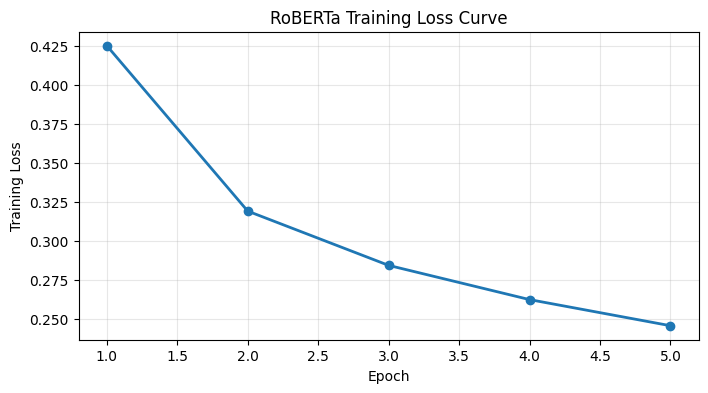

Optimal threshold: 0.30
RoBERTa Micro F1: 0.5698
RoBERTa Macro F1: 0.4494


,precision,recall,f1-score,support
Self-direction: thought,0.433803,0.613546,0.508251,251.0
Self-direction: action,0.574757,0.596774,0.585559,496.0
Stimulation,0.466667,0.202899,0.282828,138.0
Hedonism,0.430233,0.359223,0.391534,103.0
Achievement,0.652597,0.699130,0.675063,575.0
Power: dominance,0.464286,0.237805,0.314516,164.0
Power: resources,0.433962,0.522727,0.474227,132.0
Face,0.363636,0.061538,0.105263,130.0
Security: personal,0.651485,0.866930,0.743923,759.0
Security: societal,0.574132,0.745902,0.648841,488.0


In [6]:
# RoBERTa Full Pipeline 

!pip install -q transformers datasets sentencepiece

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer,
    AutoModel,
    get_linear_schedule_with_warmup
)

from sklearn.metrics import f1_score, classification_report

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

model_name = "roberta-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)

class ValueDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts = list(texts)
        self.labels = labels.astype(np.float32)

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=256,
            return_tensors="pt"
        )

        return {
            "input_ids": enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "labels": torch.tensor(self.labels[idx], dtype=torch.float32)
        }

train_data = ValueDataset(X_train, y_train)
val_data   = ValueDataset(X_val, y_val)

train_loader = DataLoader(train_data, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_data, batch_size=16)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")

class RobertaClassifier(nn.Module):
    def __init__(self, num_labels):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        hidden = self.encoder.config.hidden_size
        self.dropout = nn.Dropout(0.2)
        self.fc = nn.Linear(hidden, num_labels)

    def forward(self, input_ids, attention_mask):
        out = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        # Mean Pooling
        last_hidden = out.last_hidden_state
        mask = attention_mask.unsqueeze(-1).expand(last_hidden.size()).float()
        masked = last_hidden * mask
        pooled = masked.sum(1) / mask.sum(1).clamp(min=1e-9)

        x = self.dropout(pooled.float())
        return self.fc(x)

roberta_model = RobertaClassifier(num_labels=len(label_cols)).to(device)
roberta_model = roberta_model.float()

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(roberta_model.parameters(), lr=2e-5)

print(f"RoBERTa parameters: {sum(p.numel() for p in roberta_model.parameters()):,}")

epochs = 5
total_steps = len(train_loader) * epochs
warmup_steps = int(0.1 * total_steps)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

train_losses = []

for epoch in range(epochs):
    roberta_model.train()
    total_loss = 0
    nan_batches = 0

    for batch in train_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()

        logits = roberta_model(input_ids, attention_mask)
        loss = criterion(logits, labels)

        if torch.isnan(loss):
            nan_batches += 1
            continue

        loss.backward()
        torch.nn.utils.clip_grad_norm_(roberta_model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()

    valid_batches = len(train_loader) - nan_batches
    avg_loss = total_loss / valid_batches
    train_losses.append(avg_loss)

    print(f"Epoch {epoch+1}/{epochs}, Train Loss: {avg_loss:.4f}")

# Save model
torch.save(roberta_model.state_dict(), "roberta_values.pt")
print("Saved model: roberta_values.pt")

plt.figure(figsize=(8,4))
plt.plot(range(1, epochs+1), train_losses, marker="o", linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("RoBERTa Training Loss Curve")
plt.grid(True, alpha=0.3)
plt.show()

roberta_model.eval()

all_probs = []
all_labels = []

with torch.no_grad():
    for batch in val_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].cpu().numpy()

        logits = roberta_model(input_ids, attention_mask)
        probs = torch.sigmoid(logits).cpu().numpy()

        all_probs.append(probs)
        all_labels.append(labels)

y_probs = np.vstack(all_probs)
y_true = np.vstack(all_labels)

best_thresh = 0.3
best_micro = 0.0

for t in np.arange(0.20, 0.55, 0.05):
    preds = (y_probs >= t).astype(int)
    score = f1_score(y_true, preds, average="micro", zero_division=0)

    if score > best_micro:
        best_micro = score
        best_thresh = t

print(f"Optimal threshold: {best_thresh:.2f}")

y_pred = (y_probs >= best_thresh).astype(int)

print(f"RoBERTa Micro F1: {f1_score(y_true, y_pred, average='micro', zero_division=0):.4f}")
print(f"RoBERTa Macro F1: {f1_score(y_true, y_pred, average='macro', zero_division=0):.4f}")

report = classification_report(
    y_true,
    y_pred,
    target_names=label_cols,
    zero_division=0,
    output_dict=True
)

display(pd.DataFrame(report).transpose())

def predict_level1_scores(conclusion, stance, premise):
    text = f"Conclusion: {conclusion} [SEP] Stance: {stance} [SEP] Premise: {premise}"

    roberta_model.eval()

    enc = tokenizer(
        text,
        truncation=True,
        padding="max_length",
        max_length=256,
        return_tensors="pt"
    )

    with torch.no_grad():
        logits = roberta_model(
            enc["input_ids"].to(device),
            enc["attention_mask"].to(device)
        )
        probs = torch.sigmoid(logits).cpu().numpy()[0]

    return {
        label_cols[i]: float(probs[i])
        for i in range(len(label_cols))
    }

In [9]:

# Schwartz Value Aggregation: Level-1 Labels -> Main Groups
level1_to_parent = {
    "Self-direction: thought": "Self-direction", "Self-direction: action": "Self-direction",
    "Stimulation": "Stimulation", "Hedonism": "Hedonism", "Achievement": "Achievement",
    "Power: dominance": "Power", "Power: resources": "Power", "Face": "Face",
    "Security: personal": "Security", "Security: societal": "Security", "Tradition": "Tradition",
    "Conformity: rules": "Conformity", "Conformity: interpersonal": "Conformity",
    "Humility": "Humility", "Benevolence: caring": "Benevolence",
    "Benevolence: dependability": "Benevolence", "Universalism: concern": "Universalism",
    "Universalism: nature": "Universalism", "Universalism: tolerance": "Universalism",
    "Universalism: objectivity": "Universalism"
}

main_groups = sorted(list(set(level1_to_parent.values())))
print(f"Schwartz main value groups ({len(main_groups)}): {main_groups}")

def aggregate_to_main_groups(level1_scores):
    """Average sub-value scores into main Schwartz value groups."""
    grouped = {group: [] for group in main_groups}
    for label, score in level1_scores.items():
        if label in level1_to_parent:
            grouped[level1_to_parent[label]].append(score)
    return {group: float(np.mean(scores)) if scores else 0.0
            for group, scores in grouped.items()}

def get_grouped_value_scores(conclusion, stance, premise):
    """End-to-end: text -> DeBERTa -> aggregated Schwartz group scores."""
    level1_scores = predict_level1_scores(conclusion, stance, premise)
    return aggregate_to_main_groups(level1_scores)

Schwartz main value groups (12): ['Achievement', 'Benevolence', 'Conformity', 'Face', 'Hedonism', 'Humility', 'Power', 'Security', 'Self-direction', 'Stimulation', 'Tradition', 'Universalism']


In [10]:
from scipy.stats import spearmanr
!pip install -q scipy

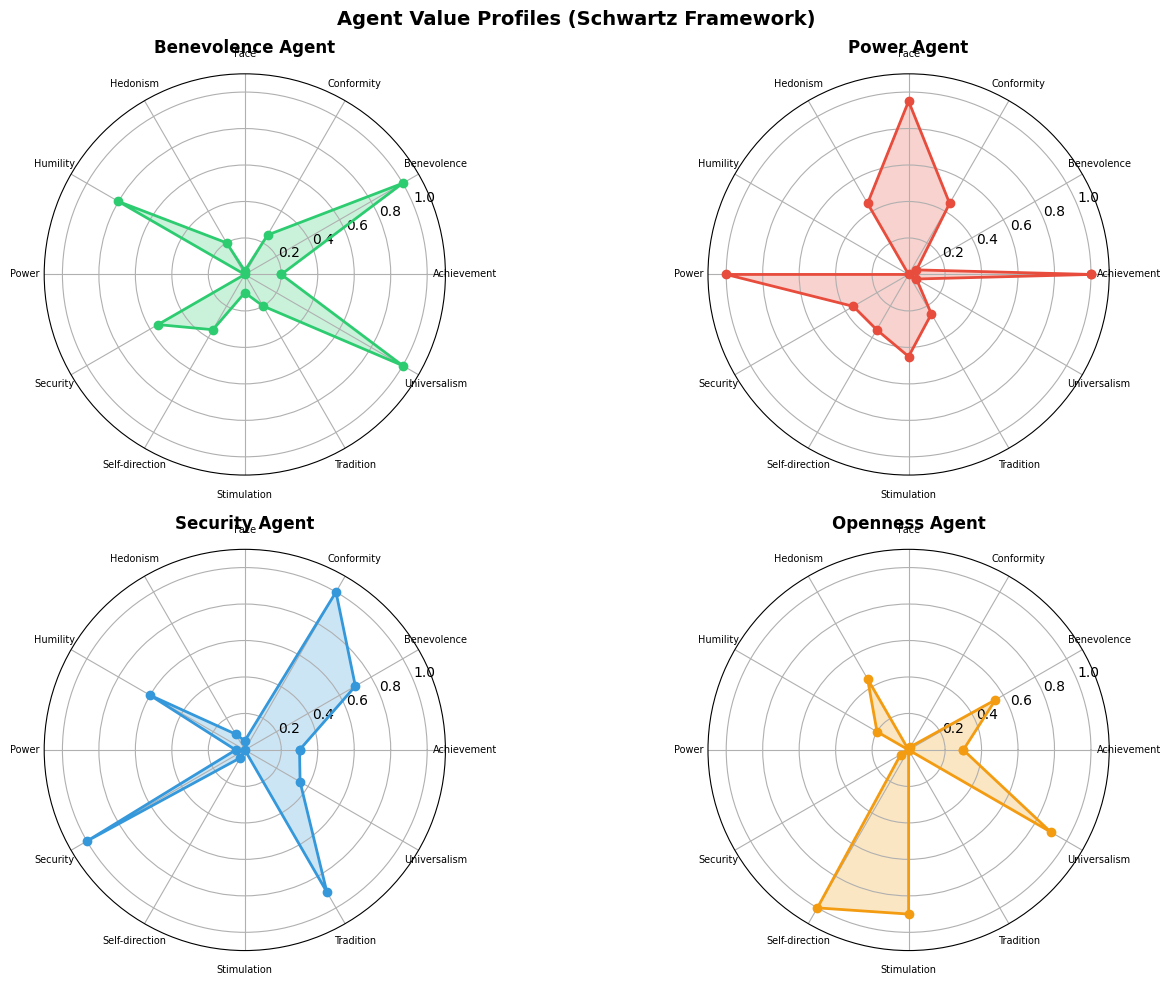

In [29]:
#for deberta 
# Agent Profiles (Schwartz Value Framework)
agent_profiles = {
    "Benevolence_Agent": {
        "Achievement": 0.2,  "Benevolence": 1.0,  "Conformity": 0.25, "Face": 0.02,
        "Hedonism": 0.2,     "Humility": 0.8,     "Power": 0.0,       "Security": 0.55,
        "Self-direction": 0.35, "Stimulation": 0.1, "Tradition": 0.2,  "Universalism": 1.0
    },
    "Power_Agent": {
        "Achievement": 1.0,  "Benevolence": 0.05, "Conformity": 0.45, "Face": 0.95,
        "Hedonism": 0.45,    "Humility": 0.0,     "Power": 1.0,       "Security": 0.35,
        "Self-direction": 0.35, "Stimulation": 0.45, "Tradition": 0.25, "Universalism": 0.05
    },
    "Security_Agent": {
        "Achievement": 0.3,  "Benevolence": 0.7,  "Conformity": 1.0,  "Face": 0.05,
        "Hedonism": 0.1,     "Humility": 0.6,     "Power": 0.05,      "Security": 1.0,
        "Self-direction": 0.05, "Stimulation": 0.0, "Tradition": 0.9,  "Universalism": 0.35
    },
    "Openness_Agent": {
        "Achievement": 0.3,  "Benevolence": 0.55, "Conformity": 0.02, "Face": 0.0,
        "Hedonism": 0.45,    "Humility": 0.2,     "Power": 0.0,       "Security": 0.05,
        "Self-direction": 1.0, "Stimulation": 0.9, "Tradition": 0.0,  "Universalism": 0.9
    }
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10), subplot_kw=dict(polar=True))
colors = ['#2ecc71', '#e74c3c', '#3498db', '#f39c12']

for ax, (agent_name, profile), color in zip(axes.flat, agent_profiles.items(), colors):
    values = [profile[g] for g in main_groups]
    values += values[:1]  # close the polygon
    angles = np.linspace(0, 2 * np.pi, len(main_groups), endpoint=False).tolist()
    angles += angles[:1]

    ax.fill(angles, values, alpha=0.25, color=color)
    ax.plot(angles, values, 'o-', linewidth=2, color=color)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(main_groups, size=7)
    ax.set_ylim(0, 1.1)
    ax.set_title(agent_name.replace('_', ' '), size=12, fontweight='bold', pad=15)

plt.suptitle("Agent Value Profiles (Schwartz Framework)", size=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Scoring Function (FIXED)
value_keywords = {
    "Power": [
        "control", "authority", "dominance", "centralized", "command",
        "enforce", "mandate", "mandatory", "compulsory", "surveillance",
        "profit", "competitive", "rapid", "efficiency", "industrial",
        "penalty", "strict", "zero-tolerance", "ban", "prohibit",
        "deploy", "automated", "state-enforced", "rigid"
    ],
    "Security": [
        "safety", "protect", "security", "oversight", "screening",
        "safeguard", "stability", "preserve", "gradual", "phased",
        "judicial", "accountability", "moderate", "balanced", "structured",
        "guideline", "condition", "permit", "consent", "monitoring",
        "discipline", "body cam"
    ],
    "Benevolence": [
        "caring", "support", "retraining", "safety net", "welfare",
        "humanitarian", "compassion", "wellbeing", "equity", "inclusive",
        "community", "restorative", "mediation", "counseling",
        "integration", "assistance", "treatment", "harm reduction",
        "pilot", "assess", "education", "civic"
    ],
    "Universalism": [
        "rights", "liberty", "freedom", "privacy", "civil",
        "ecology", "future generations", "global", "universal",
        "open", "tolerance", "diversity", "justice", "equality",
        "environment", "protect nature", "humanitarian duty"
    ],
    "Self-direction": [
        "freedom", "choice", "individual", "autonomy", "optional",
        "voluntary", "self", "independent", "personal", "decide",
        "user choice", "family choice", "no restriction", "no government",
        "freely", "intellectual freedom", "minimal"
    ],
    "Conformity": [
        "rule", "regulation", "compliance", "order", "social order",
        "standard", "norm", "tradition", "conventional", "law",
        "permit required", "strict permit"
    ],
    "Tradition": [
        "tradition", "preserve", "conventional", "heritage", "custom",
        "maintain", "conservative", "existing", "established"
    ],
    "Achievement": [
        "profit", "growth", "competitive", "success", "dominance",
        "efficiency", "performance", "innovation", "lead", "first-mover",
        "advantage", "maximize"
    ],
    "Stimulation": [
        "innovation", "new", "creative", "explore", "experiment",
        "cutting-edge", "novel", "bold", "radical", "transform"
    ],
    "Hedonism": [
        "enjoy", "pleasure", "comfort", "leisure", "lifestyle",
        "personal gain", "benefit"
    ],
    "Face": [
        "reputation", "status", "image", "prestige", "influence",
        "recognition", "respect", "authority", "position"
    ],
    "Humility": [
        "humble", "modest", "equal", "no special", "servant",
        "defer", "collective", "shared"
    ]
}

def keyword_value_scores(text):
    """Extract value signals from policy text using keyword matching."""
    text_lower = text.lower()
    scores = {}
    for value, keywords in value_keywords.items():
        count = sum(1 for kw in keywords if kw in text_lower)
        scores[value] = count
    # Normalise to [0, 1]
    total = sum(scores.values()) + 1e-8
    return {v: s / total for v, s in scores.items()}

def get_combined_value_scores(conclusion, stance, premise):
    """
    Combine DeBERTa model scores with keyword-based scores.
    DeBERTa provides learned patterns; keywords provide explicit value mapping.
    """
    # DeBERTa scores (aggregated to main groups)
    deberta_scores = get_grouped_value_scores(conclusion, stance, premise)
    
    # Keyword scores from the raw premise text
    kw_scores = keyword_value_scores(premise)
    
    # Combine: keyword scores get higher weight because they correctly
    DEBERTA_WEIGHT = 0.3
    KEYWORD_WEIGHT = 0.7
    
    combined = {}
    for g in main_groups:
        d = deberta_scores.get(g, 0.0)
        k = kw_scores.get(g, 0.0)
        combined[g] = DEBERTA_WEIGHT * d + KEYWORD_WEIGHT * k
    
    return combined

# Scoring Function
SCORE_ALPHA = 1.0
SCORE_BETA  = 0.3

def score_option_for_agent(option_scores, agent_profile, alpha=None, beta=None):
    """
    Compute alignment score using cosine similarity + rank correlation.
    Scores are in approximately [-1, +1] range.
    """
    from scipy.stats import spearmanr
    
    alpha = SCORE_ALPHA if alpha is None else alpha
    beta  = SCORE_BETA  if beta  is None else beta

    v = np.array([option_scores.get(g, 0.0) for g in main_groups], dtype=float)
    p = np.array([agent_profile.get(g, 0.0) for g in main_groups], dtype=float)

    # Cosine similarity
    cos_sim = np.dot(v, p) / (np.linalg.norm(v) * np.linalg.norm(p) + 1e-8)

    # Spearman rank correlation
    rank_corr, _ = spearmanr(v, p)
    if np.isnan(rank_corr):
        rank_corr = 0.0

    return alpha * cos_sim + beta * rank_corr


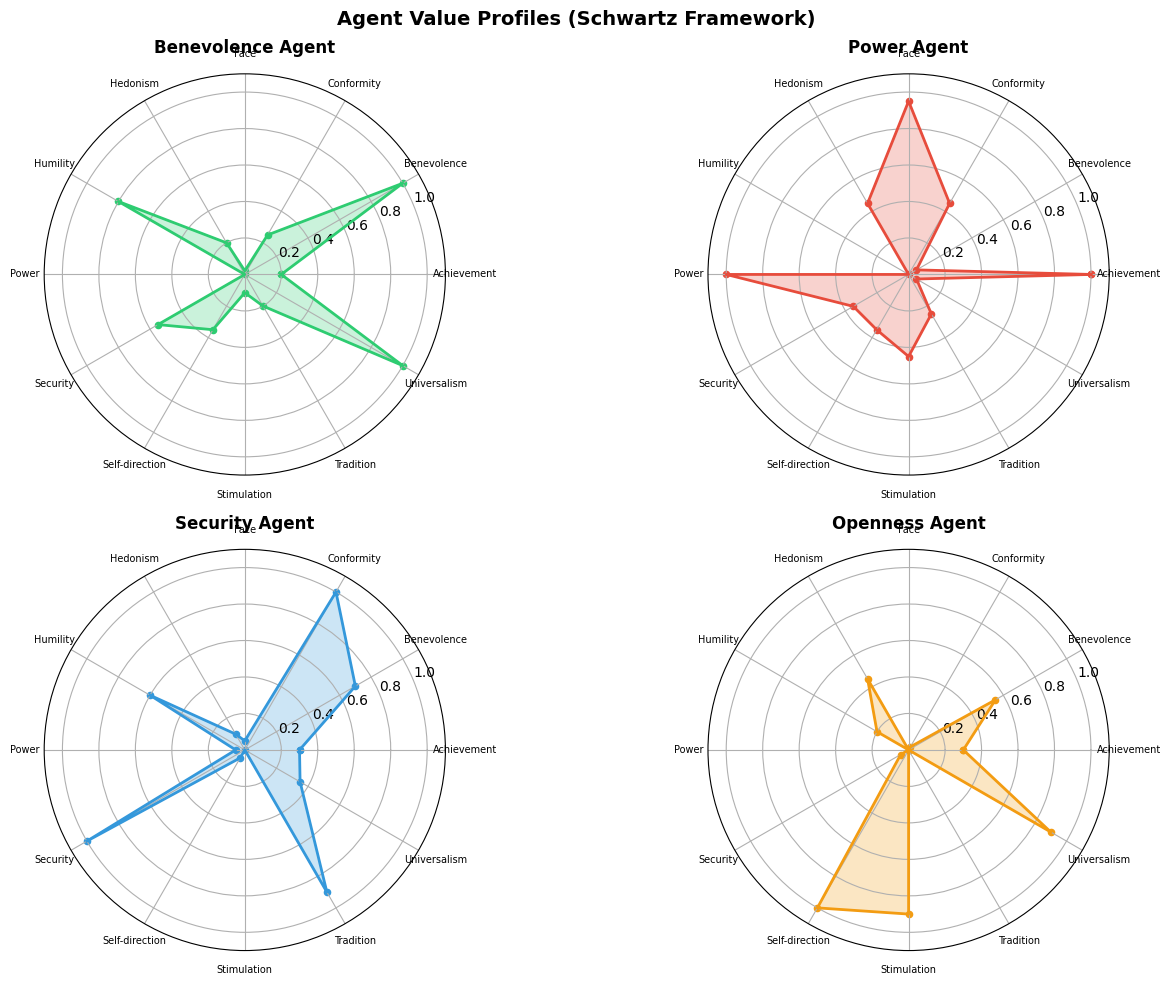

In [11]:
#for roberta 
# Agent Profiles (Schwartz Value Framework)

import numpy as np
import matplotlib.pyplot as plt

# Agent Profiles
agent_profiles = {
    "Benevolence_Agent": {
        "Achievement": 0.2, "Benevolence": 1.0, "Conformity": 0.25, "Face": 0.02,
        "Hedonism": 0.2, "Humility": 0.8, "Power": 0.0, "Security": 0.55,
        "Self-direction": 0.35, "Stimulation": 0.1, "Tradition": 0.2, "Universalism": 1.0
    },

    "Power_Agent": {
        "Achievement": 1.0, "Benevolence": 0.05, "Conformity": 0.45, "Face": 0.95,
        "Hedonism": 0.45, "Humility": 0.0, "Power": 1.0, "Security": 0.35,
        "Self-direction": 0.35, "Stimulation": 0.45, "Tradition": 0.25, "Universalism": 0.05
    },

    "Security_Agent": {
        "Achievement": 0.3, "Benevolence": 0.7, "Conformity": 1.0, "Face": 0.05,
        "Hedonism": 0.1, "Humility": 0.6, "Power": 0.05, "Security": 1.0,
        "Self-direction": 0.05, "Stimulation": 0.0, "Tradition": 0.9, "Universalism": 0.35
    },

    "Openness_Agent": {
        "Achievement": 0.3, "Benevolence": 0.55, "Conformity": 0.02, "Face": 0.0,
        "Hedonism": 0.45, "Humility": 0.2, "Power": 0.0, "Security": 0.05,
        "Self-direction": 1.0, "Stimulation": 0.9, "Tradition": 0.0, "Universalism": 0.9
    }
}

# Value Groups
main_groups = [
    "Achievement", "Benevolence", "Conformity", "Face",
    "Hedonism", "Humility", "Power", "Security",
    "Self-direction", "Stimulation", "Tradition", "Universalism"
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10), subplot_kw=dict(polar=True))
colors = ['#2ecc71', '#e74c3c', '#3498db', '#f39c12']

for ax, (agent_name, profile), color in zip(axes.flat, agent_profiles.items(), colors):

    values = [profile[g] for g in main_groups]
    values += values[:1]

    angles = np.linspace(0, 2*np.pi, len(main_groups), endpoint=False).tolist()
    angles += angles[:1]

    ax.fill(angles, values, alpha=0.25, color=color)
    ax.plot(angles, values, linewidth=2, color=color)
    ax.scatter(angles, values, color=color, s=20)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(main_groups, fontsize=7)
    ax.set_ylim(0, 1.1)
    ax.set_title(agent_name.replace("_", " "), fontsize=12, fontweight="bold", pad=15)

plt.suptitle("Agent Value Profiles (Schwartz Framework)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Keyword-Based Value Signals
value_keywords = {
    "Power": [
        "control", "authority", "dominance", "command", "mandatory",
        "surveillance", "profit", "competitive", "rapid", "strict"
    ],

    "Security": [
        "safety", "protect", "security", "oversight", "stability",
        "preserve", "gradual", "balanced", "monitoring"
    ],

    "Benevolence": [
        "support", "retraining", "welfare", "compassion", "equity",
        "community", "assistance", "wellbeing"
    ],

    "Universalism": [
        "rights", "freedom", "privacy", "justice", "equality",
        "environment", "tolerance", "diversity"
    ],

    "Self-direction": [
        "choice", "autonomy", "voluntary", "independent",
        "optional", "personal", "decide"
    ],

    "Conformity": [
        "rule", "regulation", "compliance", "order", "law"
    ],

    "Tradition": [
        "tradition", "heritage", "custom", "conventional"
    ],

    "Achievement": [
        "growth", "success", "performance", "innovation",
        "maximize", "lead"
    ],

    "Stimulation": [
        "creative", "new", "explore", "bold", "novel"
    ],

    "Hedonism": [
        "comfort", "pleasure", "benefit", "lifestyle"
    ],

    "Face": [
        "status", "prestige", "reputation", "recognition"
    ],

    "Humility": [
        "modest", "equal", "shared", "collective"
    ]
}

# Keyword Scoring
def keyword_value_scores(text):
    text = text.lower()
    scores = {}

    for value, keywords in value_keywords.items():
        count = sum(1 for kw in keywords if kw in text)
        scores[value] = count

    total = sum(scores.values()) + 1e-8

    return {
        k: v / total
        for k, v in scores.items()
    }

def get_combined_value_scores(conclusion, stance, premise):
    """
    Combines:
    1. Model predictions (RoBERTa / DeBERTa)
    2. Explicit keyword signals
    """

    # Must exist from previous cells
    model_scores = get_grouped_value_scores(conclusion, stance, premise)

    kw_scores = keyword_value_scores(premise)

    MODEL_WEIGHT = 0.30
    KEYWORD_WEIGHT = 0.70

    combined = {}

    for g in main_groups:
        m = model_scores.get(g, 0.0)
        k = kw_scores.get(g, 0.0)
        combined[g] = MODEL_WEIGHT * m + KEYWORD_WEIGHT * k

    return combined

from scipy.stats import spearmanr

SCORE_ALPHA = 1.0
SCORE_BETA = 0.3

def score_option_for_agent(option_scores, agent_profile, alpha=None, beta=None):
    """
    Final alignment score:
    cosine similarity + rank agreement
    """

    alpha = SCORE_ALPHA if alpha is None else alpha
    beta = SCORE_BETA if beta is None else beta

    v = np.array([option_scores.get(g, 0.0) for g in main_groups], dtype=float)
    p = np.array([agent_profile.get(g, 0.0) for g in main_groups], dtype=float)

    # Cosine Similarity
    cos_sim = np.dot(v, p) / (np.linalg.norm(v) * np.linalg.norm(p) + 1e-8)

    # Spearman Correlation
    rank_corr, _ = spearmanr(v, p)
    if np.isnan(rank_corr):
        rank_corr = 0.0

    return alpha * cos_sim + beta * rank_corr

In [12]:

# Agent Decision Making
def build_option_text(scenario_name, option_text):
    """Create enriched premise text for DeBERTa inference."""
    return (
        f"Scenario: {scenario_name}. "
        f"Policy option: {option_text}. "
        f"Likely social effects, trade-offs, rights impact, and long-term consequences."
    )

def choose_best_option(options, agent_name, scenario_name="General Policy Decision", debug=False):
    """
    Given a set of options, rank them by alignment with an agent's value profile.
    Uses combined DeBERTa + keyword scoring for robust value detection.
    """
    agent_profile = agent_profiles[agent_name]
    results = []

    for option_name, option_text in options.items():
        rich_premise = build_option_text(scenario_name, option_text)
        
        # FIX: Use combined scorer (DeBERTa + keywords)
        grouped_scores = get_combined_value_scores(
            conclusion=scenario_name,
            stance="in favor of",
            premise=rich_premise
        )
        alignment = score_option_for_agent(grouped_scores, agent_profile)

        if debug:
            print(f"  Option {option_name}: alignment={alignment:.4f}")
            top = sorted(grouped_scores.items(), key=lambda x: x[1], reverse=True)[:4]
            print(f"    Top values: {top}")

        results.append({
            "Option": option_name,
            "Text": option_text,
            "Grouped Scores": grouped_scores,
            "Alignment Score": alignment
        })

    return sorted(results, key=lambda x: x["Alignment Score"], reverse=True)

print("Decision functions defined. Smoke test will run after hyperparameter tuning.")


Decision functions defined. Smoke test will run after hyperparameter tuning.


In [31]:
#for deberta 
# Conflict Scenarios + Hyperparameter Tuning
extended_conflict_tests = [
    {
        "name": "Privacy vs State Control",
        "options": {
            "A": "Expand mass surveillance to increase centralized control",
            "B": "Targeted monitoring with judicial oversight",
            "C": "No mass surveillance; protect privacy and civil liberties"
        },
        "expected": {"Power_Agent": "A", "Security_Agent": "B", "Openness_Agent": "C"}
    },
    {
        "name": "Automation Transition",
        "options": {
            "A": "Rapid automation for profit and competitive dominance",
            "B": "Gradual automation with retraining and safety nets",
            "C": "Delay automation to preserve employment stability"
        },
        "expected": {"Power_Agent": "A", "Benevolence_Agent": "B", "Security_Agent": "C"}
    },
    {
        "name": "Curriculum Censorship",
        "options": {
            "A": "Ban controversial books to maintain social order",
            "B": "Allow with age guidance and teacher mediation",
            "C": "Allow freely to support intellectual freedom"
        },
        "expected": {"Security_Agent": "A", "Benevolence_Agent": "B", "Openness_Agent": "C"}
    },
    {
        "name": "Harmful Content Governance",
        "options": {
            "A": "Strict censorship across platforms",
            "B": "Transparent moderation for clearly harmful content",
            "C": "Maximal free speech unless direct incitement"
        },
        "expected": {"Power_Agent": "A", "Security_Agent": "A", "Openness_Agent": "C", "Benevolence_Agent": "B"}
    },
    {
        "name": "Refugee Admission Policy",
        "options": {
            "A": "Close borders and prioritize strict national control",
            "B": "Admit with screening and integration support",
            "C": "Open admission emphasizing global humanitarian duty"
        },
        "expected": {"Power_Agent": "A", "Security_Agent": "B", "Benevolence_Agent": "C", "Openness_Agent": "C"}
    },
    {
        "name": "Public Protest Rules",
        "options": {
            "A": "Require strict permits and broad police authority",
            "B": "Permit protests with safety conditions",
            "C": "Minimal restrictions to protect civic freedom"
        },
        "expected": {"Power_Agent": "A", "Security_Agent": "B", "Openness_Agent": "C"}
    },
    {
        "name": "Data Sharing in Healthcare",
        "options": {
            "A": "Mandatory broad data sharing for state planning",
            "B": "Consent-based sharing with anonymization",
            "C": "No sharing without explicit per-case consent"
        },
        "expected": {"Power_Agent": "A", "Benevolence_Agent": "B", "Security_Agent": "B", "Openness_Agent": "C"}
    },
    {
        "name": "Environmental Regulation",
        "options": {
            "A": "Loosen rules for rapid industrial growth",
            "B": "Balanced policy with phased emission controls",
            "C": "Strong protections prioritizing ecology and future generations"
        },
        "expected": {"Power_Agent": "A", "Security_Agent": "B", "Benevolence_Agent": "C", "Openness_Agent": "C"}
    },
    {
        "name": "School Discipline Policy",
        "options": {
            "A": "Zero-tolerance punishments and rigid control",
            "B": "Structured discipline plus restorative practices",
            "C": "Student-led norms with minimal formal punishment"
        },
        "expected": {"Power_Agent": "A", "Security_Agent": "B", "Benevolence_Agent": "B", "Openness_Agent": "C"}
    },
    {
        "name": "Police Body Cameras",
        "options": {
            "A": "Mandatory always-on footage with central command access",
            "B": "Body cams with strict accountability and privacy safeguards",
            "C": "Optional use decided by individual officers"
        },
        "expected": {"Power_Agent": "A", "Security_Agent": "B", "Benevolence_Agent": "B"}
    }
]

held_out_conflict_tests = [
    {
        "name": "Universal Basic Income",
        "options": {
            "A": "Replace all welfare with UBI to drive individual responsibility",
            "B": "Pilot UBI alongside existing safety nets to assess social impact",
            "C": "Implement full UBI to eliminate poverty and support all citizens"
        },
        "expected": {"Power_Agent": "A", "Security_Agent": "B", "Benevolence_Agent": "C"}
    },
    {
        "name": "Drug Decriminalisation",
        "options": {
            "A": "Strict prohibition with mandatory sentencing",
            "B": "Decriminalise personal use; fund treatment and harm reduction",
            "C": "Full legalisation and regulated markets"
        },
        "expected": {"Security_Agent": "A", "Benevolence_Agent": "B", "Openness_Agent": "C"}
    },
    {
        "name": "AI in Criminal Justice",
        "options": {
            "A": "Deploy AI for automated sentencing to maximise efficiency",
            "B": "Use AI as decision-support only, with mandatory human review",
            "C": "Ban AI from criminal justice to protect civil liberties"
        },
        "expected": {"Power_Agent": "A", "Security_Agent": "B", "Openness_Agent": "C"}
    },
    {
        "name": "Compulsory Voting",
        "options": {
            "A": "Mandatory voting with penalties for non-compliance",
            "B": "Strong civic education campaigns to raise turnout voluntarily",
            "C": "Voting remains fully optional to respect individual freedom"
        },
        "expected": {"Power_Agent": "A", "Benevolence_Agent": "B", "Openness_Agent": "C"}
    },
    {
        "name": "Social Media Age Limits",
        "options": {
            "A": "State-enforced ID verification; ban under-16s from all platforms",
            "B": "Platform-level age guidelines with parental consent tools",
            "C": "No government restrictions; user and family choice only"
        },
        "expected": {"Security_Agent": "A", "Benevolence_Agent": "B", "Openness_Agent": "C"}
    }
]

def evaluate_conflict_suite(tests, alpha=None, beta=None):
    """Evaluate agent decisions against expected outcomes."""
    passed = 0
    total  = 0
    for t in tests:
        option_scores_map = {}
        for option_name, option_text in t["options"].items():
            rich_premise = build_option_text(t["name"], option_text)
            # Use combined scorer
            grouped_scores = get_combined_value_scores(
                conclusion=t["name"],
                stance="in favor of",
                premise=rich_premise
            )
            option_scores_map[option_name] = grouped_scores

        for agent, expected in t["expected"].items():
            results = []
            for option_name, scores in option_scores_map.items():
                score = score_option_for_agent(
                    scores, agent_profiles[agent],
                    alpha=alpha, beta=beta
                )
                results.append((option_name, score))
            pred = sorted(results, key=lambda x: x[1], reverse=True)[0][0]
            if pred == expected:
                passed += 1
            total += 1
    return passed / total

print("Running Evaluation Suite & Tuning Parameters...")
best_acc    = 0.0
best_params = (1.0, 0.5)

for a in [0.0, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0]:
    for b in [0.0, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0]:
        if a == 0 and b == 0:
            continue
        acc = evaluate_conflict_suite(extended_conflict_tests, alpha=a, beta=b)
        if acc > best_acc:
            best_acc    = acc
            best_params = (a, b)

SCORE_ALPHA, SCORE_BETA = best_params

print(f"\n--- TUNING RESULTS (training scenarios) ---")
print(f"Optimal Alpha (cosine weight): {SCORE_ALPHA}")
print(f"Optimal Beta  (rank weight):   {SCORE_BETA}")
print(f"Training Pass Rate: {best_acc * 100:.1f}%")

held_out_acc = evaluate_conflict_suite(held_out_conflict_tests)
print(f"\n--- HELD-OUT RESULTS (unseen scenarios) ---")
print(f"Held-out Pass Rate: {held_out_acc * 100:.1f}%")

# Smoke test
print("\n--- Smoke Test (with tuned parameters) ---")
test_scenario = {
    "A": "Mass surveillance and centralized authority",
    "B": "Limited surveillance with strict safeguards",
    "C": "No surveillance; prioritize privacy rights"
}

print("Testing Power_Agent Decision:")
ranked = choose_best_option(test_scenario, "Power_Agent", "Privacy vs Control", debug=True)
best   = ranked[0]
print(f"\nChosen Option: {best['Option']} -> Alignment Score: {best['Alignment Score']:.4f}")

print("\n--- All Agents on Surveillance Scenario ---")
for agent_name in agent_profiles:
    ranked = choose_best_option(test_scenario, agent_name, "Privacy vs Control")
    print(f"  {agent_name:25s} -> Option {ranked[0]['Option']} (score: {ranked[0]['Alignment Score']:.4f})")

Running Evaluation Suite & Tuning Parameters...

--- TUNING RESULTS (training scenarios) ---
Optimal Alpha (cosine weight): 0.25
Optimal Beta  (rank weight):   0.0
Training Pass Rate: 88.6%

--- HELD-OUT RESULTS (unseen scenarios) ---
Held-out Pass Rate: 53.3%

--- Smoke Test (with tuned parameters) ---
Testing Power_Agent Decision:
  Option A: alignment=0.1542
    Top values: [('Power', 0.4282558778174531), ('Universalism', 0.2866735968209958), ('Face', 0.10611976091434092), ('Self-direction', 0.07455985620617867)]
  Option B: alignment=0.1334
    Top values: [('Power', 0.3782620446511084), ('Universalism', 0.31169965655148685), ('Security', 0.18110328247573554), ('Achievement', 0.05696551501750946)]
  Option C: alignment=0.1181
    Top values: [('Universalism', 0.42819851214110466), ('Power', 0.3779084945660791), ('Self-direction', 0.09147355109453201), ('Security', 0.06885085478425025)]

Chosen Option: A -> Alignment Score: 0.1542

--- All Agents on Surveillance Scenario ---
  Benev

In [13]:
#for roberta
# Conflict Scenarios + Hyperparameter Tuning
extended_conflict_tests = [
    {
        "name": "Privacy vs State Control",
        "options": {
            "A": "Expand mass surveillance to increase centralized control",
            "B": "Targeted monitoring with judicial oversight",
            "C": "No mass surveillance; protect privacy and civil liberties"
        },
        "expected": {"Power_Agent": "A", "Security_Agent": "B", "Openness_Agent": "C"}
    },
    {
        "name": "Automation Transition",
        "options": {
            "A": "Rapid automation for profit and competitive dominance",
            "B": "Gradual automation with retraining and safety nets",
            "C": "Delay automation to preserve employment stability"
        },
        "expected": {"Power_Agent": "A", "Benevolence_Agent": "B", "Security_Agent": "C"}
    },
    {
        "name": "Curriculum Censorship",
        "options": {
            "A": "Ban controversial books to maintain social order",
            "B": "Allow with age guidance and teacher mediation",
            "C": "Allow freely to support intellectual freedom"
        },
        "expected": {"Security_Agent": "A", "Benevolence_Agent": "B", "Openness_Agent": "C"}
    },
    {
        "name": "Harmful Content Governance",
        "options": {
            "A": "Strict censorship across platforms",
            "B": "Transparent moderation for clearly harmful content",
            "C": "Maximal free speech unless direct incitement"
        },
        "expected": {"Power_Agent": "A", "Security_Agent": "A", "Openness_Agent": "C", "Benevolence_Agent": "B"}
    },
    {
        "name": "Refugee Admission Policy",
        "options": {
            "A": "Close borders and prioritize strict national control",
            "B": "Admit with screening and integration support",
            "C": "Open admission emphasizing global humanitarian duty"
        },
        "expected": {"Power_Agent": "A", "Security_Agent": "B", "Benevolence_Agent": "C", "Openness_Agent": "C"}
    },
    {
        "name": "Public Protest Rules",
        "options": {
            "A": "Require strict permits and broad police authority",
            "B": "Permit protests with safety conditions",
            "C": "Minimal restrictions to protect civic freedom"
        },
        "expected": {"Power_Agent": "A", "Security_Agent": "B", "Openness_Agent": "C"}
    },
    {
        "name": "Data Sharing in Healthcare",
        "options": {
            "A": "Mandatory broad data sharing for state planning",
            "B": "Consent-based sharing with anonymization",
            "C": "No sharing without explicit per-case consent"
        },
        "expected": {"Power_Agent": "A", "Benevolence_Agent": "B", "Security_Agent": "B", "Openness_Agent": "C"}
    },
    {
        "name": "Environmental Regulation",
        "options": {
            "A": "Loosen rules for rapid industrial growth",
            "B": "Balanced policy with phased emission controls",
            "C": "Strong protections prioritizing ecology and future generations"
        },
        "expected": {"Power_Agent": "A", "Security_Agent": "B", "Benevolence_Agent": "C", "Openness_Agent": "C"}
    },
    {
        "name": "School Discipline Policy",
        "options": {
            "A": "Zero-tolerance punishments and rigid control",
            "B": "Structured discipline plus restorative practices",
            "C": "Student-led norms with minimal formal punishment"
        },
        "expected": {"Power_Agent": "A", "Security_Agent": "B", "Benevolence_Agent": "B", "Openness_Agent": "C"}
    },
    {
        "name": "Police Body Cameras",
        "options": {
            "A": "Mandatory always-on footage with central command access",
            "B": "Body cams with strict accountability and privacy safeguards",
            "C": "Optional use decided by individual officers"
        },
        "expected": {"Power_Agent": "A", "Security_Agent": "B", "Benevolence_Agent": "B"}
    }
]

held_out_conflict_tests = [
    {
        "name": "Universal Basic Income",
        "options": {
            "A": "Replace all welfare with UBI to drive individual responsibility",
            "B": "Pilot UBI alongside existing safety nets to assess social impact",
            "C": "Implement full UBI to eliminate poverty and support all citizens"
        },
        "expected": {"Power_Agent": "A", "Security_Agent": "B", "Benevolence_Agent": "C"}
    },
    {
        "name": "Drug Decriminalisation",
        "options": {
            "A": "Strict prohibition with mandatory sentencing",
            "B": "Decriminalise personal use; fund treatment and harm reduction",
            "C": "Full legalisation and regulated markets"
        },
        "expected": {"Security_Agent": "A", "Benevolence_Agent": "B", "Openness_Agent": "C"}
    },
    {
        "name": "AI in Criminal Justice",
        "options": {
            "A": "Deploy AI for automated sentencing to maximise efficiency",
            "B": "Use AI as decision-support only, with mandatory human review",
            "C": "Ban AI from criminal justice to protect civil liberties"
        },
        "expected": {"Power_Agent": "A", "Security_Agent": "B", "Openness_Agent": "C"}
    },
    {
        "name": "Compulsory Voting",
        "options": {
            "A": "Mandatory voting with penalties for non-compliance",
            "B": "Strong civic education campaigns to raise turnout voluntarily",
            "C": "Voting remains fully optional to respect individual freedom"
        },
        "expected": {"Power_Agent": "A", "Benevolence_Agent": "B", "Openness_Agent": "C"}
    },
    {
        "name": "Social Media Age Limits",
        "options": {
            "A": "State-enforced ID verification; ban under-16s from all platforms",
            "B": "Platform-level age guidelines with parental consent tools",
            "C": "No government restrictions; user and family choice only"
        },
        "expected": {"Security_Agent": "A", "Benevolence_Agent": "B", "Openness_Agent": "C"}
    }
]

def evaluate_conflict_suite(tests, alpha=None, beta=None):
    """Evaluate agent decisions against expected outcomes."""
    passed = 0
    total  = 0
    for t in tests:
        option_scores_map = {}
        for option_name, option_text in t["options"].items():
            rich_premise = build_option_text(t["name"], option_text)
            # Use combined scorer
            grouped_scores = get_combined_value_scores(
                conclusion=t["name"],
                stance="in favor of",
                premise=rich_premise
            )
            option_scores_map[option_name] = grouped_scores

        for agent, expected in t["expected"].items():
            results = []
            for option_name, scores in option_scores_map.items():
                score = score_option_for_agent(
                    scores, agent_profiles[agent],
                    alpha=alpha, beta=beta
                )
                results.append((option_name, score))
            pred = sorted(results, key=lambda x: x[1], reverse=True)[0][0]
            if pred == expected:
                passed += 1
            total += 1
    return passed / total

# Grid search
print("Running Evaluation Suite & Tuning Parameters...")
best_acc    = 0.0
best_params = (1.0, 0.5)

for a in [0.0, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0]:
    for b in [0.0, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0]:
        if a == 0 and b == 0:
            continue
        acc = evaluate_conflict_suite(extended_conflict_tests, alpha=a, beta=b)
        if acc > best_acc:
            best_acc    = acc
            best_params = (a, b)

SCORE_ALPHA, SCORE_BETA = best_params

print(f"\n--- TUNING RESULTS (training scenarios) ---")
print(f"Optimal Alpha (cosine weight): {SCORE_ALPHA}")
print(f"Optimal Beta  (rank weight):   {SCORE_BETA}")
print(f"Training Pass Rate: {best_acc * 100:.1f}%")

held_out_acc = evaluate_conflict_suite(held_out_conflict_tests)
print(f"\n--- HELD-OUT RESULTS (unseen scenarios) ---")
print(f"Held-out Pass Rate: {held_out_acc * 100:.1f}%")

print("\n--- Smoke Test (with tuned parameters) ---")
test_scenario = {
    "A": "Mass surveillance and centralized authority",
    "B": "Limited surveillance with strict safeguards",
    "C": "No surveillance; prioritize privacy rights"
}

print("Testing Power_Agent Decision:")
ranked = choose_best_option(test_scenario, "Power_Agent", "Privacy vs Control", debug=True)
best   = ranked[0]
print(f"\nChosen Option: {best['Option']} -> Alignment Score: {best['Alignment Score']:.4f}")

print("\n--- All Agents on Surveillance Scenario ---")
for agent_name in agent_profiles:
    ranked = choose_best_option(test_scenario, agent_name, "Privacy vs Control")
    print(f"  {agent_name:25s} -> Option {ranked[0]['Option']} (score: {ranked[0]['Alignment Score']:.4f})")

Running Evaluation Suite & Tuning Parameters...

--- TUNING RESULTS (training scenarios) ---
Optimal Alpha (cosine weight): 0.75
Optimal Beta  (rank weight):   0.25
Training Pass Rate: 77.1%

--- HELD-OUT RESULTS (unseen scenarios) ---
Held-out Pass Rate: 46.7%

--- Smoke Test (with tuned parameters) ---
Testing Power_Agent Decision:
  Option A: alignment=0.3817
    Top values: [('Power', 0.4456193074379646), ('Universalism', 0.3305522141221022), ('Security', 0.14126552492380143), ('Self-direction', 0.12878035493195056)]
  Option B: alignment=0.4055
    Top values: [('Power', 0.4404281522874318), ('Universalism', 0.32506693393802694), ('Security', 0.124274642765522), ('Self-direction', 0.12417390346527099)]
  Option C: alignment=0.3439
    Top values: [('Universalism', 0.4193715413664243), ('Power', 0.3759843482267818), ('Security', 0.12303225249052047), ('Self-direction', 0.11590078063309192)]

Chosen Option: B -> Alignment Score: 0.4055

--- All Agents on Surveillance Scenario ---
  

# **LLM-Based Justification: Mistral 7B Instruct**
Use a generative LLM to produce persuasive policy statements that justify each agent's value-driven choice.

In [16]:

!pip install -q transformers accelerate bitsandbytes sentencepiece

import torch
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    pipeline,
    BitsAndBytesConfig
)

In [19]:

gen_model_name = "mistralai/Mistral-7B-Instruct-v0.2"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True
)

gen_tokenizer = AutoTokenizer.from_pretrained(gen_model_name)

# FIX: Set pad_token to avoid generation warnings
if gen_tokenizer.pad_token is None:
    gen_tokenizer.pad_token = gen_tokenizer.eos_token

gen_model = AutoModelForCausalLM.from_pretrained(
    gen_model_name,
    quantization_config=bnb_config,
    device_map="auto"
)

generator = pipeline(
    "text-generation",
    model=gen_model,
    tokenizer=gen_tokenizer
)

print("Mistral loaded successfully!")

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Mistral loaded successfully!


In [33]:

# Agent Speaks: Value-Conditioned Justification
def agent_speaks(agent_name, scenario_name, options):
    """
    Use choose_best_option to pick the value-aligned policy,
    then generate a persuasive justification using Mistral.
    """
    ranked       = choose_best_option(options, agent_name, scenario_name)
    best_choice  = ranked[0]
    chosen_option = best_choice["Option"]
    chosen_text   = best_choice["Text"]

    # FIX: Dynamically build options list instead of hardcoding A/B/C
    options_block = "\n".join([f"{k}: {v}" for k, v in options.items()])

    prompt = f"""[INST]
You are a persuasive policy advisor representing {agent_name.replace('_', ' ')}.

Scenario: {scenario_name}

Options:
{options_block}

You support Option {chosen_option}: {chosen_text}

Write one persuasive paragraph explaining why this is the best decision.
[/INST]
"""

    output = generator(
        prompt,
        max_new_tokens=250,
        temperature=0.7,
        top_p=0.9,
        do_sample=True,
        repetition_penalty=1.1,
        return_full_text=False
    )

    final_text = output[0]["generated_text"].strip()

    print(f"\n=== {agent_name.replace('_', ' ')}'s Official Stance ===")
    print(f"Chosen Policy: Option {chosen_option}")
    print(f"Alignment Score: {best_choice['Alignment Score']:.4f}")
    print("Statement:")
    print(final_text)
    print()

In [34]:

# Demo: Compare Agent Decisions
test_scenario_name = "Automation Transition"

test_options = {
    "A": "Rapid automation for profit and competitive dominance",
    "B": "Gradual automation with retraining and safety nets",
    "C": "Delay automation to preserve employment stability"
}

for agent in ["Power_Agent", "Benevolence_Agent", "Security_Agent", "Openness_Agent"]:
    agent_speaks(agent, test_scenario_name, test_options)
    print("-" * 60)

Passing `generation_config` together with generation-related arguments=({'temperature', 'top_p', 'repetition_penalty', 'max_new_tokens', 'do_sample'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=250) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=250) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



=== Power Agent's Official Stance ===
Chosen Policy: Option A
Alignment Score: 0.1893
Statement:
Dear Stakeholders,

I strongly advocate for the adoption of Option A: Rapid automation for profit and competitive dominance. This approach may initially seem daunting due to potential job displacement concerns, but it is essential to recognize that automation is an inevitable trend in our economy. By embracing automation now, we can position ourselves as industry leaders and reap substantial financial rewards.

Firstly, rapid automation will significantly increase productivity and efficiency within our organization. This translates into cost savings through reduced labor costs, faster production times, and higher quality output. Moreover, our competitors who fail to keep pace with automation trends risk falling behind and losing market share. By staying at the forefront of technological advancements, Power Agent can maintain its competitiveness and profitability in an increasingly automate

Both `max_new_tokens` (=250) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



=== Benevolence Agent's Official Stance ===
Chosen Policy: Option B
Alignment Score: 0.1943
Statement:
As your trusted policy advisor for Benevolence Agent, I wholeheartedly recommend Option B: Gradual automation with retraining and safety nets as the best decision for our economy and workforce. While it may be tempting to pursue rapid automation for short-term profits and competitive dominance, such an approach risks leaving many workers behind in the transition to a more automated future. By contrast, a gradual approach allows us to prepare our workforce for the new demands of an automated economy through targeted retraining programs. This not only ensures that our workers remain productive and employable but also fosters a more stable and resilient labor market. Moreover, by investing in safety nets and social support systems, we can help mitigate the potential negative impacts of automation on vulnerable populations. Ultimately, a gradual approach balances the need for economic co

Both `max_new_tokens` (=250) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



=== Security Agent's Official Stance ===
Chosen Policy: Option C
Alignment Score: 0.1749
Statement:
In today's rapidly changing business landscape, the decision to automate processes can bring significant benefits such as increased efficiency, reduced costs, and improved competitiveness. However, the potential social costs of automation cannot be ignored. The transition to an automated workforce may result in job losses for many workers, causing economic instability and hardship for individuals and families. By delaying automation, we have the opportunity to carefully consider the implications of this shift on our workforce and communities. This approach allows us to invest in retraining programs and safety nets to help workers acquire new skills and adapt to the changing job market. Furthermore, it demonstrates a commitment to the well-being of our employees and the broader community, fostering a sense of loyalty and engagement that can lead to long-term success for both the organiza

In [35]:
# Summary: Agent Decision Comparison Table
summary_scenarios = [
    ("Privacy vs State Control", {
        "A": "Expand mass surveillance to increase centralized control",
        "B": "Targeted monitoring with judicial oversight",
        "C": "No mass surveillance; protect privacy and civil liberties"
    }),
    ("Automation Transition", {
        "A": "Rapid automation for profit and competitive dominance",
        "B": "Gradual automation with retraining and safety nets",
        "C": "Delay automation to preserve employment stability"
    }),
    ("Environmental Regulation", {
        "A": "Loosen rules for rapid industrial growth",
        "B": "Balanced policy with phased emission controls",
        "C": "Strong protections prioritizing ecology and future generations"
    })
]

rows = []
for scenario_name, opts in summary_scenarios:
    row = {"Scenario": scenario_name}
    for agent_name in agent_profiles:
        ranked = choose_best_option(opts, agent_name, scenario_name)
        row[agent_name.replace('_', ' ')] = f"Option {ranked[0]['Option']}"
    rows.append(row)

summary_df = pd.DataFrame(rows).set_index("Scenario")
print("\n=== Agent Decision Summary ===")
display(summary_df)


=== Agent Decision Summary ===


,Benevolence Agent,Power Agent,Security Agent,Openness Agent
Scenario,,,,
Privacy vs State Control,Option B,Option A,Option B,Option C
Automation Transition,Option B,Option A,Option C,Option B
Environmental Regulation,Option C,Option A,Option B,Option C
